#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import scipy
import random
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from math import pi
from scipy.interpolate import NearestNDInterpolator

%matplotlib inline

#floris simulation modules
from floris.tools.wind_rose import WindRose
from floris.tools import FlorisInterface
import floris.tools.visualization as wakeviz
from floris.turbine_library import TurbineInterface, TurbineLibrary
from floris.tools.visualization import (
    calculate_horizontal_plane_with_turbines,
    visualize_cut_plane,
)

## Optimized Layouts

### WInd Rose

In [2]:
df_wind_montly = pd.read_csv('./2020_Daily_Avgs.csv')
df_wind_montly.head()

list_wd_bins = [0., 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80., 85., 90., 95., 100., 105., 110., 115., 120., 125., 130., 135., 140., 145., 150., 155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205., 210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260., 265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315., 320., 325., 330., 335., 340., 345., 350., 355.]

list_ws_bins = [0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.]

windr = WindRose()

df_wind_calc = windr.make_wind_rose_from_user_data(wd_raw=df_wind_montly['average_wind_dir_deg'], ws_raw=df_wind_montly['Factorized_Mean'], wd=np.array(list_wd_bins), ws=np.array(list_ws_bins))


wd_array = np.array(df_wind_calc["wd"].unique(), dtype=float)
ws_array = np.array(df_wind_calc["ws"].unique(), dtype=float)


wd_grid, ws_grid = np.meshgrid(wd_array, ws_array, indexing="ij")
freq_interp = NearestNDInterpolator(df_wind_calc[["wd", "ws"]], df_wind_calc["freq_val"])
freq = freq_interp(wd_grid, ws_grid)

# Normalize the frequency array to sum to exactly 1.0
freq = freq / np.sum(freq)

Correcting negative Overhang:-2.5


### Floris Interface

In [3]:
fi_nrel = FlorisInterface('./gch.yaml')
fi_vestas = FlorisInterface('./gch_vestas.yaml')

In [4]:
def aep_powers(fi, df):
    power_list = []
    fi.reinitialize(
        layout_x=df["Layout_x"],
        layout_y=df['Layout_y'],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list

#### Defining Populations

#### Defining Parameters

In [5]:
lenth_factor = 0.01
area_factor = lenth_factor**2


turbines_diameter = 52

max_tubines = 45
min_turbines = 30
 
min_diastance = turbines_diameter 
max_distance = turbines_diameter * 20


tournament_size = 3
target_coverage_area = 800000 
mutation_rate = 0.01

no_of_gens = 20

### The GA Implmentation

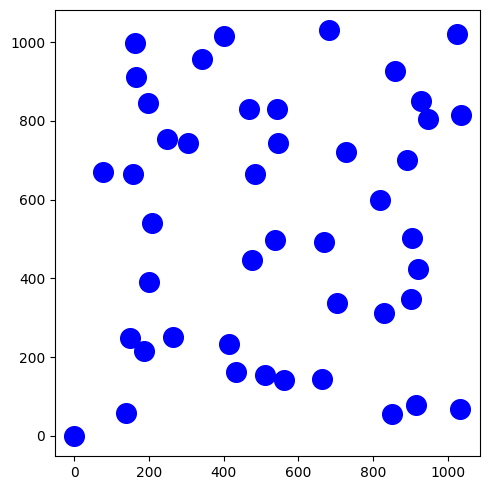

       Layout_x     Layout_y
0      0.000000     0.000000
1    545.145068   744.619118
2    413.824344   233.590104
3    858.522646   925.894292
4    669.579155   492.607424
5    185.800760   216.380285
6    199.700742   392.244066
7   1031.381003    68.085509
8     77.099738   671.063674
9    208.650263   541.287205
10   475.133259   447.861303
11   914.464617    79.517916
12   680.582253  1030.234258
13   928.747069   851.793060
14   903.427361   502.846379
15  1033.928129   816.144972
16   467.648312   830.825852
17   342.687439   956.775010
18   484.131302   665.196905
19   543.112157   830.450939
20   431.826199   162.675837
21   150.384256   249.326210
22   401.334430  1016.209407
23  1023.939565  1020.463084
24   818.722428   598.922423
25   164.869553   912.129288
26   510.152055   155.732513
27   727.910797   719.932231
28   157.344149   664.062826
29   946.780782   804.148446
30   305.564078   742.792821
31   830.094138   312.688276
32   537.861855   498.936111
33   920.22765

In [6]:
def initialize_populations():
    populations = []
    for num_turbines in np.repeat(range(min_turbines + 1, max_tubines + 1), 1):  # Generate 24 initial populations
        layout = pd.DataFrame(columns=['Layout_x', 'Layout_y'])
        layout.loc[0] = [0, 0]  # Set the first turbine at the origin
        for _ in range(1, num_turbines):
            while True:
                new_turbine = pd.DataFrame(np.random.uniform(min_diastance, max_distance, size=(1, 2)), columns=['Layout_x', 'Layout_y'])
                if all(np.linalg.norm(layout[['Layout_x', 'Layout_y']].values - new_turbine.values, axis=1) >= min_diastance):
                    temp_df = pd.concat([layout, new_turbine], ignore_index=True)
                    layout = temp_df.copy()  # Assign the concatenated DataFrame back to layout
                    break
        populations.append(layout)
    return populations


def calculate_fitness(layout):
    num_turbines = len(layout)
    distances = scipy.spatial.distance.pdist(layout[['Layout_x', 'Layout_y']].values)
    epsilon = 1e-7  # small constant to avoid division by zero
    wake_effect = np.sum(1 / (distances + epsilon))
    return num_turbines - wake_effect

def tournament_selection(populations):
    tournament = random.sample(populations, tournament_size)
    return max(tournament, key=calculate_fitness)

def crossover(parent1, parent2):
    min_length = min(len(parent1), len(parent2))
    child = parent1.copy()

    for column in child.columns:
        random_mask = np.random.rand(min_length) < 0.5
        child_vals = np.where(random_mask, parent1[column][:min_length], parent2[column][:min_length])
        child[column][:min_length] = child_vals

    return child

def mutate(df):
    if np.random.rand() < mutation_rate:
        if len(df) > min_turbines:  # If there are more than min_turbines turbines, remove one with a certain probability
            df = df.drop(np.random.choice(df.index[1:]))  # Do not remove the turbine at the origin
        elif len(df) < max_tubines:  # If there are less than max_turbines turbines, add one with a certain probability
            while True:
                new_turbine = pd.DataFrame(np.random.uniform(min_diastance, max_distance, size=(1, 2)), columns=['Layout_x', 'Layout_y'])  # Generate coordinates between min_distance and max_distance meters
                if all(np.linalg.norm(df[['Layout_x', 'Layout_y']].values - new_turbine.values, axis=1) >= min_diastance):
                    df = pd.concat([df, new_turbine], ignore_index=True)  # Add the new turbine to the DataFrame
                    break
    return df
# def mutate(df):
#     if np.random.rand() < mutation_rate:
#         if len(df) > 3:  # If there are more than 3 turbines, remove one with a certain probability
#             df = df.drop(np.random.choice(df.index[1:]))  # Do not remove the turbine at the origin
#         elif len(df) < 10:  # If there are less than 10 turbines, add one with a certain probability
#             while True:
#                 new_turbine = pd.DataFrame(np.random.uniform(126, 630, size=(1, 2)), columns=['Layout_x', 'Layout_y'])  # Generate coordinates between 126 and 630 meters
#                 if all(np.linalg.norm(df[['Layout_x', 'Layout_y']].values - new_turbine.values, axis=1) >= 126):
#                     df = pd.concat([df, new_turbine], ignore_index=True)
#                     break
#     return df

def calculate_enclosed_area(layout):
    points = layout[['Layout_x', 'Layout_y']].values
    hull = ConvexHull(points)
    return hull.volume



# def calculate_enclosed_area(layout):
#     points = layout[['Layout_x', 'Layout_y']].values
#     if len(points) < 3 or np.all(np.cross(points[1:] - points[0], points[1:] - points[-1]) == 0):
#         return 0  # Points are collinear, return 0 for the enclosed area
#     else:
#         hull = ConvexHull(points)
#         return hull.volume

def run_genetic_algorithm(populations):
    best_layouts = {i: None for i in range(min_turbines, max_tubines + 1)}  # Initialize a dictionary to store the best layout for each number of turbines

    for _ in range(20):
        next_gen = []
        for _ in range(len(populations)):
            parent1 = tournament_selection(populations)
            parent2 = tournament_selection(populations)
            child = crossover(parent1, parent2)
            child = mutate(child)
            next_gen.append(child)
        populations = next_gen

    # Sort populations by fitness and enclosed area
    populations.sort(key=lambda p: (calculate_fitness(p), -calculate_enclosed_area(p)), reverse=True)

    # Update best_layouts with the best layout for each number of turbines
    for population in populations:
        num_turbines = len(population)
        if 3 <= num_turbines <= max_tubines and best_layouts[num_turbines] is None and calculate_enclosed_area(population) <= target_coverage_area:
            best_layouts[num_turbines] = population

    # If all layouts exceed 800,000 sq meters, return the one with the smallest area
    for num_turbines in range(min_turbines, max_tubines + 1):
        if best_layouts[num_turbines] is None:
            best_layouts[num_turbines] = min(populations, key=calculate_enclosed_area)

    # Return a layout with a random number of turbines from 3 to 8
    return best_layouts[np.random.choice(range(min_turbines, max_tubines))]

def plot_best_layout(best_layout):
    fig, ax = plt.subplots(figsize=(5, 5))  # Adjust subplot configuration
    ax.scatter(best_layout['Layout_x'], best_layout['Layout_y'], c='b', s=200)
    # ax.set_title('Best Layout')
    plt.tight_layout()
    plt.show()

def main():
    populations = initialize_populations()
    best_layout = run_genetic_algorithm(populations)  # Get only the best layout

    plot_best_layout(best_layout)  # Plot only the best layout
    print(best_layout)
    print("Enclosed area: ", calculate_enclosed_area(best_layout))

if __name__ == "__main__":
    main()

In [7]:
def plot_best_layouts(best_layout):
    fig, ax = plt.subplots(figsize=(5, 5))  # Adjust subplot configuration
    ax.scatter(best_layout['Layout_x'], best_layout['Layout_y'], c='b', s=200)

    # Calculate and plot Convex Hull
    points = best_layout[['Layout_x', 'Layout_y']].values
    hull = ConvexHull(points)
    for simplex in hull.simplices:
        ax.plot(points[simplex, 0], points[simplex, 1], 'k-')

    # Shade the area enclosed by the Convex Hull
    ax.fill(points[hull.vertices,0], points[hull.vertices,1], 'k', alpha=0.3)

In [8]:
def powers(fi, gen_1_pop):
    power_list = []
    fi.reinitialize(
        layout_x=gen_1_pop["Layout_x"],
        layout_y=gen_1_pop['Layout_y'],
        wind_directions=wd_array,
        wind_speeds=ws_array,
    )

    aep = fi.get_farm_AEP(
        freq=freq,
        cut_in_wind_speed=4.0,  # Wakes are not evaluated below this wind speed
        cut_out_wind_speed=25.0,  # Wakes are not evaluated above this wind speed
    )
    power_list.append(round((aep / 1.0e9), 3))

    aep_no_wake = fi.get_farm_AEP(freq, no_wake=True)
    power_list.append(round((aep_no_wake / 1.0e9), 3))

    percentage_power_loss = (aep_no_wake - aep) / aep_no_wake * 100
    power_list.append(round(percentage_power_loss, 3))


    return power_list


# nrel_p1_powers[]
# populations = initialize_populations()
# gen_1_pop = get_gen1_populations()

# for _ in range(len(gen_1_pop)):
#     nrel_p1_powers = powers(fi_vestas, gen_1_pop[_])
#     print(nrel_p1_powers)

# for _ in range(len(populations)):
#     nrel_p1_powers = powers(fi_nrel, populations[_])
#     print(nrel_p1_powers)
# nrel_p1_powers = powers(fi_nrel, gen_1_pop[0])
# nrel_p1_powers

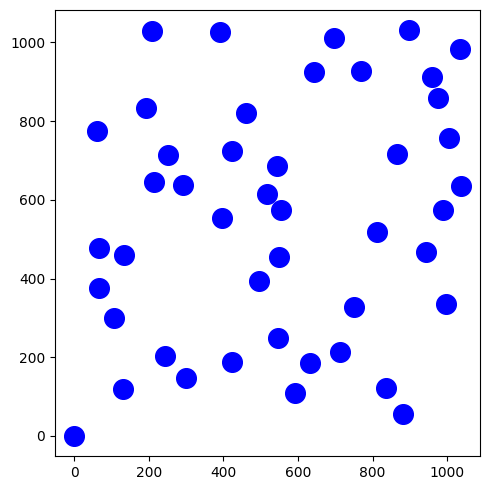

939362.2331317159


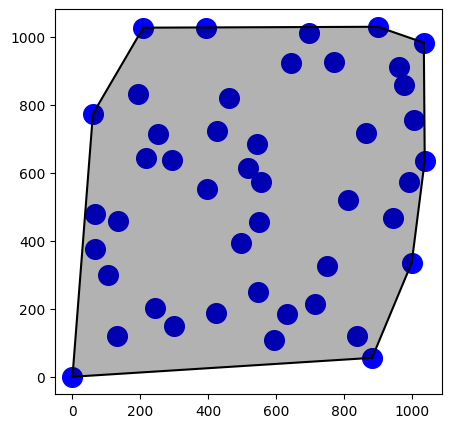

In [9]:
populations = initialize_populations()
best_layout = run_genetic_algorithm(populations)  # Get only the best layout
plot_best_layout(best_layout)  # Plot only the best layout
plot_best_layouts(best_layout)
print(calculate_enclosed_area(best_layout))
len(best_layout)

def get_gen1_populations():
    gen_1_pop = []
    for _ in range(5):
        best_layout = run_genetic_algorithm(populations)
        gen_1_pop.append(best_layout)
    return gen_1_pop

gen_1_pop = get_gen1_populations()

In [10]:
print(powers(fi_vestas, best_layout))
len(best_layout)

[47.625, 92.734, 48.643]


45

In [11]:
# def find_ct(c_p):
#     ct = c_p  # Initial guess
#     epsilon = 1e-6  # Tolerance for convergence

#     while True:
#         new_ct = (ct + ct * (1 - ct)**0.5) / 2
#         if abs(new_ct - ct) < epsilon:
#             break
#         ct = new_ct

#     return ct

# # Find Ct for Cp = 0.1, 0.3, 0.41
# cp_values = [0.1, 0.3, 0.41]

# for cp in cp_values:
#     ct_result = find_ct(cp)
#     print(f"For Cp = {cp}, Ct = {ct_result}")


In [12]:
df_area = pd.DataFrame()
df_area['Layout_x'] = [0, 0, 4, 4, 2]
df_area['Layout_y'] = [0, 4, 0, 4, 2]
df_area
calculate_enclosed_area(df_area)

16.0

  ### Floris Initailization

In [13]:
data = {
    "Layout_y": [9846029.731, 9846197.111, 9846323.489, 9846423.521, 9846551.776, 9846743.266, 9846862.862, 9846981.229, 9847123.455, 9847380.825, 9847736.504, 9847881.979, 9847950.427, 9847815.822, 9848019.373, 9848107.184, 9847489.094, 9847936.821, 9847820.906, 9847734.012, 9847634.116, 9847532.026, 9847397.188, 9847256.911, 9847179.492, 9847312.767, 9847411.651, 9847536.334, 9847499.008, 9847518.827],
    "Layout_x": [2376.781, 2375.137, 2361.911, 2349.034, 2334.965, 2321.065, 2317.616, 2309.323, 2295.723, 2239.071, 2222.141, 2196.289, 2186.89, 2212.672, 2179.715, 2162.664, 2183.999, 2214.963, 2230.508, 2241.077, 2239.893, 2228.47, 2243.351, 2277.398, 2296.216, 2262.404, 2237.125, 2194.764, 2201.937, 2212.847]
}

df_actual = pd.DataFrame(data)

In [14]:
actual_powers = powers(fi_vestas, df_actual)
print(actual_powers)    

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


[44.382, 61.823, 28.211]


In [15]:
calculate_enclosed_area(df_actual)

103809.00521930247

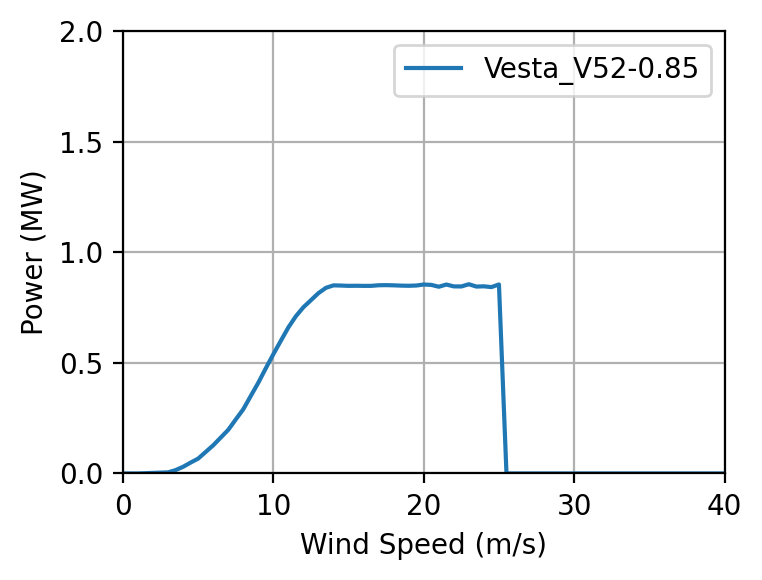

In [16]:
ti_vestas = TurbineInterface.from_yaml("Vesta_V52-0.85.yaml")
ti_vestas.plot_power_curve()

In [17]:


gen_2 = []
while len(gen_2) < 3:
    try:
        best_layout = run_genetic_algorithm(populations)
        nrel_p1_powers = powers(fi_nrel, best_layout)
        if nrel_p1_powers[2] < 20:
            gen_2.append(best_layout)
    except Exception as e:
        print(f"An error occurred: {e}")
        continue

len(gen_2)

floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.
floris.tools.floris_interface.FlorisInterface WARNING Some rotor effective velocities are negative.


KeyboardInterrupt: 

In [ ]:
print(powers(fi_nrel, gen_2[0]))
print(powers(fi_nrel, gen_2[1]))
print(powers(fi_nrel, gen_2[2]))

In [ ]:
# print(gen_2[0])
# print(gen_2[1])
# print(gen_2[2])

In [ ]:
populations.to_csv('populations_0.csv')

In [ ]:
gen_2[0].to_csv('v1.csv')
gen_2[1].to_csv('v2.csv')
gen_2[2].to_csv('v3.csv')

In [ ]:
power_outputs = []
for layout in gen_1_pop:
    power_output = powers(fi_nrel, layout)
    power_outputs.append(power_output)

In [ ]:
import matplotlib.pyplot as plt

# Assuming power_outputs is a list of lists, where each sublist is [aep, aep_no_wake, percentage_power_loss]
aep_values = [output[0] for output in power_outputs]
aep_no_wake_values = [output[1] for output in power_outputs]
percentage_power_loss_values = [output[2] for output in power_outputs]

# Create a new figure
plt.figure()

# Create a bar plot for aep values
plt.bar(range(len(aep_values)), aep_values, color='b', alpha=0.7, label='AEP')

# Create a bar plot for aep_no_wake values
plt.bar(range(len(aep_no_wake_values)), aep_no_wake_values, color='r', alpha=0.7, label='AEP No Wake')

# Create a bar plot for percentage_power_loss values
plt.bar(range(len(percentage_power_loss_values)), percentage_power_loss_values, color='g', alpha=0.7, label='Percentage Power Loss')

# Add labels and title
plt.xlabel('Layout')
plt.ylabel('Power Output')
plt.title('Power Output of Wind Farm Layouts')
plt.legend()

# Show the plot
plt.show()